# Polish Bankruptcy Dataset

The Polish Bankruptcy Prediction dataset was collected from the Emerging Markets Information Service (EMIS), a database that provides information on emerging markets worldwide, for the period 2007 to 2013 for bankrupt companies and 2000 to 2012 for still operating companies. According to the data source and Tomczak et al. (2016), who analyzed this dataset, it was decided to focus on financial data from the manufacturing sector. In Poland, since 2004, many companies in this sector have gone bankrupt, and it was possible to obtain representative samples. The dataset is publicly available through the UC Irvine Machine Learning Repository.

In [6]:
import pandas as pd
from pathlib import Path

In [7]:
# from ucimlrepo import fetch_ucirepo 
  
# # fetch dataset 
# polish_companies_bankruptcy = fetch_ucirepo(id=365) 
  
# # data (as pandas dataframes) 
# X = polish_companies_bankruptcy.data.features 
# y = polish_companies_bankruptcy.data.targets 
  
# # metadata 
# print(polish_companies_bankruptcy.metadata) 
  
# # variable information 
# print(polish_companies_bankruptcy.variables) 

In [8]:
# df = pd.concat([X, y], axis=1)
# df.head()

In [9]:
# # I can also load a sepaarte file

# from scipy.io import arff
# import pandas as pd

# data, meta = arff.loadarff("5year.arff")

# df_5 = pd.DataFrame(data)

# print(df.head())

In [10]:
# df_5.info()

In [11]:
# # save this dataset for further analysis

# OUTPUT_DIR = Path.cwd() / "PL_bankruptcy_dataset"
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# OUTPUT_PARQUET_PATH = OUTPUT_DIR / "PL_bankruptcy_dataset.parquet"
# OUTPUT_CSV_PATH = OUTPUT_DIR / "PL_bankruptcy_dataset.csv"

# df.to_parquet(OUTPUT_PARQUET_PATH, index=False)

# # I wqill save CSV only because I want an "easy-to-open" inspection file.
# # Parquet is better for the further work because it keeps dtypes better and is smaller/faster.
# df.to_csv(OUTPUT_CSV_PATH, index=False)

# print("Saved Parquet file to:", OUTPUT_PARQUET_PATH)
# print("Saved CSV file to:", OUTPUT_CSV_PATH)
# print("Final shape:", df.shape)

In [12]:
# # Save metadata
# import json

# OUTPUT_METADATA_PATH = OUTPUT_DIR / "PL_bankruptcy_metadata.json"

# metadata = polish_companies_bankruptcy.metadata

# with open(OUTPUT_METADATA_PATH, "w", encoding="utf-8") as f:
#     json.dump(metadata, f, indent=4, ensure_ascii=False, default=str)

# print("Saved metadata file to:", OUTPUT_METADATA_PATH)


In [13]:
# load metadata

import json

OUTPUT_DIR = Path.cwd() / "PL_bankruptcy_dataset"

OUTPUT_METADATA_PATH = OUTPUT_DIR / "PL_bankruptcy_metadata.json"

with open(OUTPUT_METADATA_PATH, "r", encoding="utf-8") as f:
    metadata_loaded = json.load(f)

metadata_loaded

{'uci_id': 365,
 'name': 'Polish Companies Bankruptcy',
 'repository_url': 'https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data',
 'data_url': 'https://archive.ics.uci.edu/static/public/365/data.csv',
 'abstract': 'The dataset is about bankruptcy prediction of Polish companies.The bankrupt companies were analyzed in the period 2000-2012, while the still operating companies were evaluated from 2007 to 2013.',
 'area': 'Business',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 10503,
 'num_features': 65,
 'feature_types': ['Real'],
 'demographics': [],
 'target_col': ['class'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 2016,
 'last_updated': 'Sat Mar 09 2024',
 'dataset_doi': '10.24432/C5F600',
 'creators': ['Sebastian Tomczak'],
 'intro_paper': {'ID': 417,
  'type': 'NATIVE',
  'title': 'Ensemble boosted trees with synthetic features generation in application

The features are well described on the source website and can be grouped into economically meaningful categories, including profitability measures (e.g., gross profit on sales), leverage and solvency ratios (e.g., total liabilities / total assets), liquidity (e.g., current assets / short-term liabilities), time-based stress indicators and efficiency metrics (e.g., sales / inventory). Those features are financially meaningful and Interpretable, but some of them may be highly redundant and correlated. Also, after initial exploration it was discovered that because of ratio-based nature some values are unstable

In [14]:
# Variables meaning
print(metadata_loaded["additional_info"]["variable_info"])

X1	net profit / total assets
X2	total liabilities / total assets
X3	working capital / total assets
X4	current assets / short-term liabilities
X5	[(cash + short-term securities + receivables - short-term liabilities) / (operating expenses - depreciation)] * 365
X6	retained earnings / total assets
X7	EBIT / total assets
X8	book value of equity / total liabilities
X9	sales / total assets
X10	equity / total assets
X11	(gross profit + extraordinary items + financial expenses) / total assets
X12	gross profit / short-term liabilities
X13	(gross profit + depreciation) / sales
X14	(gross profit + interest) / total assets
X15	(total liabilities * 365) / (gross profit + depreciation)
X16	(gross profit + depreciation) / total liabilities
X17	total assets / total liabilities
X18	gross profit / total assets
X19	gross profit / sales
X20	(inventory * 365) / sales
X21	sales (n) / sales (n-1)
X22	profit on operating activities / total assets
X23	net profit / sales
X24	gross profit (in 3 years) / total a

Data analysis start!

In [15]:
from pathlib import Path

PROJECT_DIR = Path.cwd() # We must be in the project directory

BANKRUPTCY_DATA_PATH = PROJECT_DIR /"PL_bankruptcy_dataset" /"PL_bankruptcy_dataset.csv" # folder for the raw file

df_bankruptcy = pd.read_csv(BANKRUPTCY_DATA_PATH)

In [16]:
df_bankruptcy.head()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
0,1,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


In [17]:
df_bankruptcy.shape

(43405, 66)

In [18]:
df_bankruptcy.columns 

Index(['year', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
       'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20',
       'A21', 'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A29', 'A30',
       'A31', 'A32', 'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40',
       'A41', 'A42', 'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50',
       'A51', 'A52', 'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60',
       'A61', 'A62', 'A63', 'A64', 'class'],
      dtype='object')

In [19]:
# describe function enable us to assess statistics such asL median and mean. 
# If we choose also paramater = all we will also observe statistics for the categorical variables, including mode

df_bankruptcy.describe()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,43405.000000,43397.000000,43397.000000,43397.000000,43271.000000,4.331600e+04,43397.000000,43397.000000,43311.000000,43396.000000,...,4.327800e+04,43398.000000,4.332100e+04,43398.000000,4.125300e+04,43303.000000,4.327800e+04,43271.000000,42593.000000,43405.000000
mean,2.939753,0.035160,0.590212,0.114431,6.314702,-3.853480e+02,-0.056107,0.093478,12.640779,2.652166,...,-2.621959e+01,-0.010510,3.002644e+01,1.333288,4.481067e+02,17.033202,1.502521e+03,9.343074,72.796105,0.048174
std,1.283975,2.994109,5.842748,5.439429,295.434425,6.122797e+04,7.201326,5.713075,505.894281,62.932732,...,5.327862e+03,13.674072,5.334454e+03,122.104445,3.234518e+04,553.049406,1.393023e+05,124.177354,2369.744596,0.214137
min,1.000000,-463.890000,-430.870000,-479.960000,-0.403110,-1.190000e+07,-508.410000,-517.480000,-141.410000,-3.496000,...,-1.108300e+06,-1667.300000,-1.986900e+02,-327.970000,-1.244000e+01,-12.656000,-2.340000e+06,-1.543200,-10677.000000,0.000000
25%,2.000000,0.003429,0.268980,0.021521,1.049500,-4.908000e+01,0.000000,0.005776,0.430275,1.018500,...,9.348500e-03,0.014649,8.753200e-01,0.000000,5.545500e+00,4.510150,4.214400e+01,3.097650,2.176800,0.000000
50%,3.000000,0.049660,0.471900,0.196610,1.569800,-1.034500e+00,0.000000,0.059634,1.070400,1.195350,...,5.294300e-02,0.119670,9.509600e-01,0.006366,9.791700e+00,6.636300,7.132600e+01,5.087600,4.282500,0.000000
75%,4.000000,0.129580,0.688320,0.403390,2.787450,5.063425e+01,0.089446,0.150880,2.615700,2.062500,...,1.290975e-01,0.284605,9.926400e-01,0.236052,2.018100e+01,10.394500,1.172200e+02,8.598850,9.776200,0.000000
max,5.000000,94.280000,480.960000,28.336000,53433.000000,1.250100e+06,543.250000,649.230000,53432.000000,9742.300000,...,2.931500e+02,552.640000,1.108300e+06,23853.000000,4.818700e+06,108000.000000,2.501600e+07,23454.000000,294770.000000,1.000000


In [20]:
# Describe() function showed that there are outliers in the dataset. Let's find the structure of the dataset using percentils in the loan_amount column. 

df_bankruptcy["A23"].quantile([
    0.00,
    0.01,
    0.05,
    0.25,
    0.50,
    0.75,
    0.90,
    0.95,
    0.99,
    0.995,
    0.9999999999,
    1.00
])

0.000   -1578.700000
0.010      -0.715164
0.050      -0.163880
0.250       0.002269
0.500       0.029916
0.750       0.078038
0.900       0.146533
0.950       0.205587
0.990       0.421892
0.995       0.652500
1.000    9230.469387
1.000    9230.500000
Name: A23, dtype: float64

In [21]:
df_bankruptcy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43405 entries, 0 to 43404
Data columns (total 66 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    43405 non-null  int64  
 1   A1      43397 non-null  float64
 2   A2      43397 non-null  float64
 3   A3      43397 non-null  float64
 4   A4      43271 non-null  float64
 5   A5      43316 non-null  float64
 6   A6      43397 non-null  float64
 7   A7      43397 non-null  float64
 8   A8      43311 non-null  float64
 9   A9      43396 non-null  float64
 10  A10     43397 non-null  float64
 11  A11     43361 non-null  float64
 12  A12     43271 non-null  float64
 13  A13     43278 non-null  float64
 14  A14     43397 non-null  float64
 15  A15     43369 non-null  float64
 16  A16     43310 non-null  float64
 17  A17     43311 non-null  float64
 18  A18     43397 non-null  float64
 19  A19     43277 non-null  float64
 20  A20     43278 non-null  float64
 21  A21     37551 non-null  float64
 22

This dataset contains 43,405 firm-year observations (rows) combined and 66 variables (64 float, 2 integers), primarily financial ratios and performance indicators. It includes a binary target variable (Bankrupt?). It is divided into 5 forecasting periods, e.g., 1st Year – the data contains financial rates from the 1st year of the forecasting period and corresponding class label that indicates bankruptcy status after 5 years, 2nd Year – the data contains financial rates from the 2nd year of the forecasting period and corresponding class label that indicates bankruptcy status after 4 years, and so on. Each of these classification cases has a different set of companies

<Axes: >

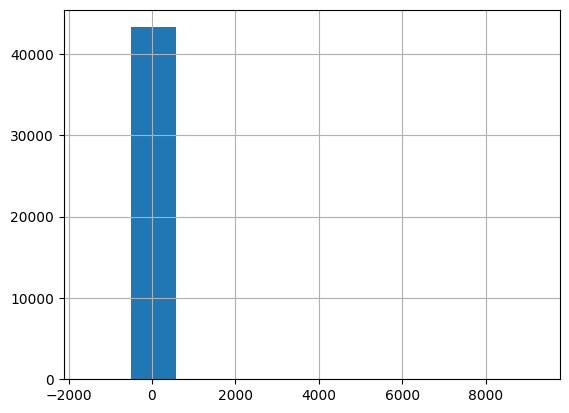

In [22]:
# We can observe a large negative and positive outliers
# we should think about winsorization of the outliers
# This value is a ratioso should be between 

df_bankruptcy["A23"].hist()

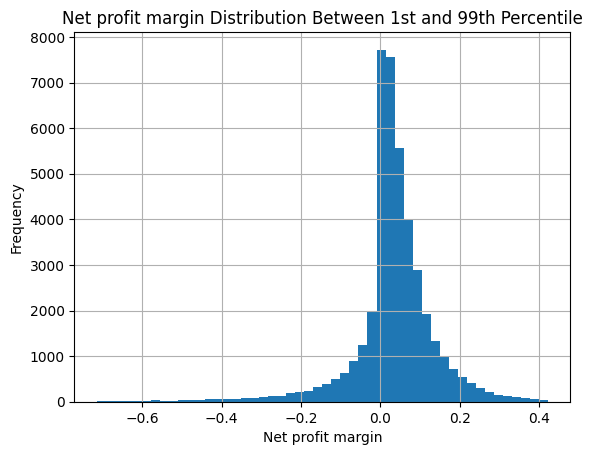

Lower limit: -0.7151643000000002
Upper limit: 0.42189150000000014


In [23]:
# Let's draw trimmed distribution. It seems much better 

import matplotlib.pyplot as plt


lower_limit = df_bankruptcy["A23"].quantile(0.01)
upper_limit = df_bankruptcy["A23"].quantile(0.99)

df_margin_trimmed = df_bankruptcy[df_bankruptcy["A23"].between(lower_limit, upper_limit)]

df_margin_trimmed["A23"].hist(bins=50)

plt.title("Net profit margin Distribution Between 1st and 99th Percentile")
plt.xlabel("Net profit margin")
plt.ylabel("Frequency")
plt.show()

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

Explanation of ratios based on net profit / sales.

$$
X_{23} = \frac{\text{Net Profit}}{\text{Sales}}
$$

A23 can be from negative infinity to positive infinity. It is not limited to 0–1. So, Ratios like this can be negative, above 1, or extremely large when sales are very small.

For normal companies, net profit margin is often somewhere around: -0.20 to 0.30.

In this bankruptcy dataset we should expect many abnormal values, such as -5, -10, 20, 100. We can observe that on the above distribution.

Why this happens? A23 tells you how much profit the company keeps from each unit of sales. For example, if A23 = 0.08, it means that for every 1 PLN of sales, the company earns 0.08 PLN of net profit.

Because a ratio is a division, and division becomes extreme when the denominator is very small. SO when sales are extremely large or extremely small we are approaching inifnity. So te ratio can explode wehn the company had almost no revenue from sales, but it recorded profit from some other source, such as: interest income, sale of an asset, debt forgiveness, extraordinary gains, accounting corrections.

In [24]:
# We should check duplicates percentage

duplicate_count = df_bankruptcy.duplicated(keep="first").sum()
duplicate_percent = duplicate_count / len(df_bankruptcy) * 100

print("Duplicate rows after first:", duplicate_count)
print(f"Duplicate percent: {duplicate_percent:.4f}%")

Duplicate rows after first: 401
Duplicate percent: 0.9239%


In [25]:
all_duplicate_rows = df_bankruptcy[df_bankruptcy.duplicated(keep= False)]

print("Rows involved in duplicate groups:", len(all_duplicate_rows))

Rows involved in duplicate groups: 802


In [26]:
# Duplicates are mostly class 0 so they are safe to remove. We do not 
df_bankruptcy["class"][df_bankruptcy.duplicated(keep="first")].value_counts()

class
0    393
1      8
Name: count, dtype: int64

In [27]:
# The most repeated profile

duplicate_profiles = (
    df_bankruptcy
    .value_counts(dropna=False)
    .reset_index(name="count")
    .query("count > 1")
    .sort_values("count", ascending=False)
)

duplicate_profiles.head(10)

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A57,A58,A59,A60,A61,A62,A63,A64,class,count
0,2,0.002549,0.017899,-0.011346,0.36611,-12974.0000,0.036629,0.002796,54.86000,0.099842,...,0.002596,10.01600,0.000000,NaN,0.043987,205000.000,0.00178,0.000032,0,2
1,2,-0.027020,0.500330,0.124580,1.25020,27.8110,0.000000,-0.027020,0.99869,1.137400,...,-0.054076,1.01990,0.000000,65.5580,16.025000,159.800,2.28410,3.013300,0,2
2,1,1.419500,0.735320,0.308130,1.61780,31.6640,0.000000,1.719700,0.35994,9.505900,...,5.363200,0.81996,0.000000,145.7000,25.278000,19.151,19.05900,49.227000,0,2
3,2,-0.033898,0.118780,0.092317,1.77720,24.3450,0.241800,-0.028614,7.41830,0.516790,...,-0.038469,0.10185,0.000000,23.2070,3.376600,83.894,4.35070,0.655100,1,2
4,1,0.142490,0.209290,0.270700,2.29340,6.1232,0.492360,0.181900,3.68690,1.085900,...,0.184660,0.92088,0.000000,23.5900,10.352000,31.881,11.44900,4.608000,0,2
5,1,0.056076,0.823480,-0.026471,0.96758,-56.8410,-0.265010,0.074617,0.21436,3.455700,...,0.317670,0.97845,0.000000,7.3042,10.923000,86.229,4.23290,16.450000,0,2
6,2,0.097767,0.133090,0.537550,5.03910,19.2520,0.000000,0.127560,6.51400,1.762700,...,0.112780,0.93076,0.000000,3.9886,12.092000,27.558,13.24500,5.351800,0,2
7,2,0.041993,0.422190,0.240950,1.74090,-9.7445,0.270350,0.055354,1.27520,1.056600,...,0.078000,0.94640,0.180160,5.3048,5.398600,85.808,4.25370,3.188200,0,2
8,2,0.082695,0.172430,0.412790,3.70070,61.2760,0.230570,0.121920,4.78740,1.139200,...,0.100180,0.87781,0.023725,4.4583,6.942700,50.346,7.24990,2.551100,0,2
9,1,0.133960,0.639820,0.250670,1.45320,12.4860,0.000000,0.167780,0.56294,2.488100,...,0.371920,0.93535,0.046490,15.3030,3.918500,81.136,4.49860,12.678000,0,2


In [28]:
# I cleaned dataset from duplicates. 
df_bankruptcy_clean = df_bankruptcy.drop_duplicates().copy()

In [29]:

df_bankruptcy_clean.duplicated().any()

np.False_

In [30]:
df_bankruptcy_clean.shape

(43004, 66)

In [31]:
df_bankruptcy_clean.isna().sum().sum() / df_bankruptcy.size

np.float64(0.014324910200961348)

In [32]:
# How many row have at least one missing value (before removing unsusable columns)
df_bankruptcy_clean.isna().any(axis=1).sum()

np.int64(23267)

In [33]:
# missing values by column
df_bankruptcy_clean.isna().sum().sort_values(ascending=False)

A37      18836
A21       5836
A27       2750
A60       2138
A45       2133
         ...  
A59          7
A57          7
A55          1
year         0
class        0
Length: 66, dtype: int64

In [34]:
# I need to drop all the columns with more than 1000 missisng values
# Missing cols to drop:
# X37	(current assets - inventories) / long-term liabilities
# X21	sales (n) / sales (n-1)
# X27	profit on operating activities / financial expenses
# X60	sales / inventory
# X45	net profit / inventory

missing_counts = df_bankruptcy_clean.isna().sum()
# select columns to drop
cols_to_drop = missing_counts[missing_counts > 1000].index
# drop them
df_bankruptcy_clean = df_bankruptcy_clean.drop(columns=cols_to_drop)

In [35]:
# verify ranking of columns with missing values
df_bankruptcy_clean.isna().sum().sort_values(ascending=False).head(10)


A24    922
A28    804
A54    804
A64    804
A53    804
A41    754
A32    366
A52    300
A47    296
A46    134
dtype: int64

In [36]:
# This counts rows with at least one missing value
df_bankruptcy_clean.isna().any(axis=1).sum()

np.int64(2887)

In [37]:
# How many missing values in general
all_missing_val = df_bankruptcy_clean.isna().sum().sum()

In [38]:
# Percentge of missing values to all the values

all_missing_val / df_bankruptcy_clean.size

np.float64(0.003562001857242407)

In [39]:
df_bankruptcy_clean[["year", "class"]].value_counts()

year  class
3     0        9923
2     0        9685
4     0        9197
1     0        6674
5     0        5442
4     1         513
3     1         493
5     1         408
2     1         398
1     1         271
Name: count, dtype: int64

In [40]:
df_bankruptcy_clean[ "year"].value_counts(normalize = False)

year
3    10416
2    10083
4     9710
1     6945
5     5850
Name: count, dtype: int64

In [41]:
df_bankruptcy_clean[ "class"].value_counts(normalize = True)

class
0    0.951563
1    0.048437
Name: proportion, dtype: float64

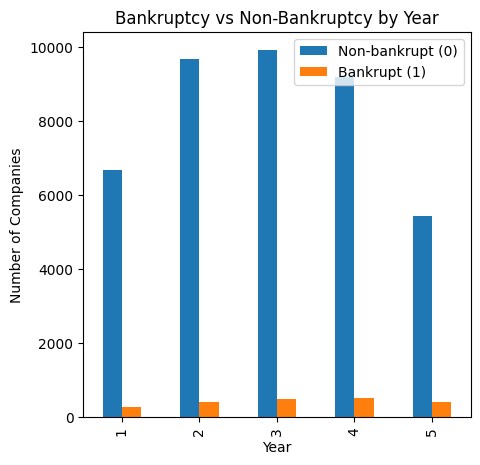

In [42]:
counts = df_bankruptcy_clean[["year", "class"]].value_counts().unstack()

import matplotlib.pyplot as plt

counts.plot(kind='bar', figsize=(5,5))

plt.title("Bankruptcy vs Non-Bankruptcy by Year")
plt.xlabel("Year")
plt.ylabel("Number of Companies")
plt.legend(["Non-bankrupt (0)", "Bankrupt (1)"])

plt.show()

In [43]:
df_bankruptcy_clean["class"].value_counts()

class
0    40921
1     2083
Name: count, dtype: int64

In [44]:
# Missing values for the dataset after iunitial clenaing

missing_table_after_cleaning = pd.DataFrame({
    "missing_count": df_bankruptcy_clean.isna().sum(),
    "missing_percent": df_bankruptcy_clean.isna().mean().mul(100).round(2),
    "dtype": df_bankruptcy_clean.dtypes.astype(str)
}).sort_values("missing_percent", ascending=False)

missing_table_after_cleaning

,missing_count,missing_percent,dtype
A24,922,2.14,float64
A28,804,1.87,float64
A54,804,1.87,float64
A64,804,1.87,float64
A53,804,1.87,float64
...,...,...,...
A51,8,0.02,float64
A57,7,0.02,float64
year,0,0.00,int64
A55,1,0.00,float64


In [ ]:
# Let's save this dataset bgefore experimenting with cliping values

OUTPUT_DIR = Path.cwd() / "PL_bankruptcy_dataset"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PARQUET_PATH = OUTPUT_DIR / "df_bankruptcy_clean.parquet"

df_bankruptcy_clean.to_parquet(OUTPUT_PARQUET_PATH, index=False)

print("Saved Parquet file to:", OUTPUT_PARQUET_PATH)
print("Final shape:", df_bankruptcy_clean.shape)

Saved Parquet file to: c:\Users\pabis\BU_University\AI_for_Leaders\PL_bankruptcy_dataset\df_bankruptcy_clean.parquet
Final shape: (43004, 61)


I can use winsorization but not blindly.I would not apply winsorization to all features indiscriminately. Instead, I would selectively clip highly skewed ratio-based variables that are prone to extreme values, while preserving meaningful variation in stable features.

Do not clip:
- Target variable
- Contsraint variable: ROA, equity/assets already bounded
- log variables: already compressed 

How cna I do it?

Step 1: identify skewed / unstable columns also we can detect unstable features where variance is huge relative to typical value and extreme range

more than 2 means very heavy-tailed / problematic

```python
skewed_cols = df.skew().abs() > 2
skewed_cols = skewed_cols[skewed_cols].index
```

Step 2 — exclude important columns

```python
exclude = ["class", "year"]
cols_to_clip = [col for col in skewed_cols if col not in exclude]
```

Step 3 — clip only selected columns

```python
df[cols_to_clip] = df[cols_to_clip].clip(
    lower=df[cols_to_clip].quantile(0.01),
    upper=df[cols_to_clip].quantile(0.99),
    axis=1
)
```

Combine logic

```python
cols_to_clip = df.columns[(df.skew().abs() > 2) & (df.columns != "class")]
```


In [46]:
skewed_cols = df_bankruptcy.skew().abs() > 2
skewed_cols = skewed_cols[skewed_cols].index
skewed_cols

Index(['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11',
       'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19', 'A20', 'A21',
       'A22', 'A23', 'A24', 'A25', 'A26', 'A27', 'A28', 'A30', 'A31', 'A32',
       'A33', 'A34', 'A35', 'A36', 'A37', 'A38', 'A39', 'A40', 'A41', 'A42',
       'A43', 'A44', 'A45', 'A46', 'A47', 'A48', 'A49', 'A50', 'A51', 'A52',
       'A53', 'A54', 'A55', 'A56', 'A57', 'A58', 'A59', 'A60', 'A61', 'A62',
       'A63', 'A64', 'class'],
      dtype='object')

In [47]:
# Winsorization = cutting extreme values, but NOT removing rows
# if value < Q1%  → replace with Q1%
# if value > Q99% → replace with Q99%
win_df = df_bankruptcy.clip(lower=df_bankruptcy.quantile(0.01), 
             upper=df_bankruptcy.quantile(0.99), 
             axis=1).copy()

In [48]:
win_df.shape

(43405, 66)

In [49]:
win_df.describe()

,year,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,class
count,43405.000000,43397.000000,43397.000000,43397.000000,43271.000000,43316.000000,43397.000000,43397.000000,43311.000000,43396.000000,...,43278.000000,43398.000000,43321.000000,43398.000000,41253.000000,43303.000000,43278.000000,43271.000000,42593.000000,43405.000000
mean,2.939753,0.061826,0.509977,0.198367,2.865850,2.752665,0.011662,0.076246,2.825798,1.701686,...,0.078858,0.144118,0.923663,0.281550,33.114227,10.281550,103.594427,7.550252,17.432320,0.048174
std,1.283975,0.164536,0.335409,0.320425,4.362008,517.945992,0.323826,0.178377,5.756014,1.229565,...,0.195039,0.584837,0.191566,0.959819,99.692257,13.425100,124.305303,8.475987,52.630218,0.214137
min,1.000000,-0.576798,0.018522,-1.000640,0.199897,-2978.500000,-1.880592,-0.572827,-0.535478,0.107161,...,-0.662779,-2.948214,0.047531,-2.657017,1.246628,0.610161,4.933659,0.293002,0.124973,0.000000
25%,2.000000,0.003429,0.268980,0.021521,1.049500,-49.080000,0.000000,0.005776,0.430275,1.018500,...,0.009348,0.014649,0.875320,0.000000,5.545500,4.510150,42.144000,3.097650,2.176800,0.000000
50%,3.000000,0.049660,0.471900,0.196610,1.569800,-1.034500,0.000000,0.059634,1.070400,1.195350,...,0.052943,0.119670,0.950960,0.006366,9.791700,6.636300,71.326000,5.087600,4.282500,0.000000
75%,4.000000,0.129580,0.688320,0.403390,2.787450,50.634250,0.089446,0.150880,2.615700,2.062500,...,0.129098,0.284605,0.992640,0.236052,20.181000,10.394500,117.220000,8.598850,9.776200,0.000000
max,5.000000,0.605991,2.056324,0.889821,32.468500,2879.175000,0.814787,0.691208,41.677300,7.553235,...,0.986716,2.810609,1.658400,6.402312,815.695600,97.639800,915.715500,57.916300,423.201200,1.000000


In [50]:
# Some variables are still heavy-tailed. They are candidates for log transform (carefully)
# log transform (carefully)
# Negative values remain so we cannot blindly apply log. We need sth like np.sign(x) * np.log1p(abs(x))
# Proper timeline
# 1. Handle missing values
# 2. Handle outliers (winsorization)   
# 3. Transform distributions (log, etc.)  ← I am here. I can think of scalling A5, A15, A55
# 4. Scale features
# 5. Model

<Axes: >

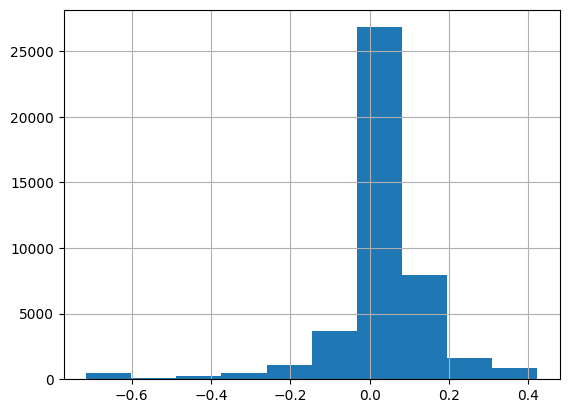

In [51]:
win_df["A23"].hist()

I have extreme values because the features are financial ratios, and ratios can explode when the denominator is small or unstable.

Most of my features look like:

 
$ ratio = \frac{something}{something else}\ $

If denominator → very small (≈ 0) then the number will be very large!

Why do we have such extreme ratios?

1. Companies near bankruptcy have:
- liabilities unstable
- profits ≈ 0
- negative cash flow
and that can cuz exploding ratios.

2. Accounting quirks
- depreciation adjustments
- one-time expenses
- extraordinary items
this can lead to tiny denominator

3. Scale difference: small companies vs large companies
-  We apply same formula and in effect obtain different magnitudes.

From the Mathematical point of view: x / y
- Ratios are non-linear transformations. If y changes slightly (eg. from 10 to 100) we can get explosion.

Why does Machine Learning hates such extreme features?
- dominate loss function
- distort gradients
- bias coefficients

Eg. If one feature = 1,000,000 model focuses ONLY on that feature

Summary:

Extreme values arise because many features are financial ratios, which can become very large when denominators are close to zero. These values are mathematically valid but can negatively affect machine learning models, so techniques like winsorization or transformation are necessary.

WQhat can we do with extremes:

- Technique 1: Winsorize + keep signal indirectly

Model sees controlled values and still relative differences

- Technique 2: Add “extreme indicator”

df["A5_extreme"] = (df["A5"] > df["A5"].quantile(0.99)).astype(int)

Now model knows: “This is an extreme company”

- Technique 3: log transform

compresses extremes instead of removing them

- Technique 4: use tree models

naturally handle extremes

We can think of extremes as flags of abnormal behavior

Summary:

Extreme values in financial data may represent genuine signals of distress rather than noise. Instead of removing them entirely, I would use techniques like winsorization combined with indicator variables to preserve their informational value while maintaining model stability.

Conclusions:

- Are the data usable?  

Yes the dataset is fully usable fo furthere analysis and training ML model.

- Do you need to modify or correct the data in some way? 

Yes. An exploratory analysis was conducted to assess the quality of variables.  Initially, this dataset contained 400 duplicates (~0.9 %), which needed to be removed. Also, 23.438 rows had at least one missing value. The overall ratio of missing values was ~1.5%. It was discovered that 5 columns, including quick assets to long term liabilities and sales-growth-ratio, are mostly the main reason for this high percentage. After the diligent assessment, it was decided that these columns can be safely removed. The final missing values were 2887 rows with at least one missing value, for a general rate of ~0.35%, which is a very satisfactory result. There are also extreme values because the features are financial ratios, and ratios can explode when the denominator is small or unstable; e.g., companies near bankruptcy can have a profit of ~0 and unstable liabilities. Extreme values in financial data may signal genuine distress rather than noise. Instead of removing them entirely, use techniques such as winsorization combined with indicator variables (flagging) to preserve their informational value while maintaining model stability. Winsorization can “clip” extreme values to the 1st and 99th percentile. Only highly skewed variables should be “clipped” (skew> 2) to preserve meaningful variation in stable features. The last steps in handling outliers should be transforming highly skewed distributions (e.g., log / signed log) and scaling the variables (e.g., StandardScaler).

- Is there any class imbalance?  (Categories that have many more items than other categories).

Despite selecting observations from the sector with the higher possibility of bankruptcy, there is  imbalance in a target variable. After initial data cleaning 2.083 of 40.921 firms (~5.1%) are bankrupt. To address this issue, techniques such as oversampling (e.g., SMOTE), undersampling, or class-weight adjustment, that is higher penalty to mistakes made on the minority class, may be applied (Wang & Liu, 2021).